# Ordering a Mock Stream with the MST Backbone


[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/GalacticDynamics/phasecurvefit/blob/main/docs/tutorials/stream_mst.ipynb)


Here we order a mock stellar stream with the `MSTOrderer`. A tidal stream's velocity field points outward from the progenitor along **both** arms — it reverses at the progenitor — so a single local-flow walk covers only one arm. The MST needs no progenitor and no start index: the graph diameter finds the two tips itself and orders the stream tip-to-tip.


In [1]:
import pathlib
import pickle

import galax.coordinates as gc
import galax.dynamics as gd
import galax.potential as gp
import jax.random as jr
import matplotlib.pyplot as plt
import numpy as np
from scipy.spatial import cKDTree

import quaxed.numpy as jnp
import unxt as u

import phasecurvefit as pcf

In [2]:
key = jr.key(201030)
usys = u.unitsystems.galactic

## Data: a mock stream

Reuses `mockstream.pkl` from the other stream tutorials.


In [3]:
prog_w0 = gc.PhaseSpaceCoordinate(
    q=u.Q([10, 3, 5], "kpc"), p=u.Q([-4, 100, 4], "km/s"), t=u.Q(0.0, "Myr")
)
prog_mass = u.Quantity(2.5e4, "Msun")
df = gd.FardalStreamDF()
pot = gp.LMJ09LogarithmicPotential(
    v_c=u.Q(150, "km/s"),
    r_s=u.Q(2, "kpc"),
    q1=1.0,
    q2=1.3,
    q3=0.9,
    phi=u.Q(0, "deg"),
    units=usys,
)
mockgen = gd.MockStreamGenerator(df, pot)

In [4]:
mockstream_path = pathlib.Path("mockstream.pkl")
with mockstream_path.open("rb") as handle:
    mockstream, prog = pickle.load(handle)  # noqa: S301

In [5]:
# Shuffle; no start index or progenitor is needed for the MST.
key, subkey = jr.split(key)
order = jr.permutation(subkey, jnp.arange(len(mockstream.q.x)))
qs = {k: getattr(mockstream.q, k)[order] for k in mockstream.q.components}
ps = {k: getattr(mockstream.p, k)[order] for k in mockstream.p.components}

## MST ordering

`jump_cap` is set from the data — the 99th percentile of nearest-neighbour distances tolerates the stream's varying density while still severing the loop-scale gaps. Real streams occasionally leave a stray point disconnected, so we keep the largest component (`on_disconnected="largest"`). No progenitor or start index is needed; `orient_by_velocity` gives `gamma` a physical direction.


In [6]:
comps = list(qs)
P = np.stack([np.asarray(u.ustrip(usys, qs[c])) for c in comps], axis=1)
nn = cKDTree(P).query(P, k=2)[0][:, 1]
jump_cap = float(np.percentile(nn, 99.98))

orderer = pcf.orderers.MSTOrderer(
    k=16,
    jump_cap=jump_cap,
    orient_by_velocity=True,
    on_disconnected="largest",
)
mstresult = orderer.order(qs, ps, metadata=pcf.StateMetadata(usys=usys))
print("coverage:", int((mstresult.indices >= 0).sum()), "/", len(mockstream.q.x))

coverage: 7998 / 8000


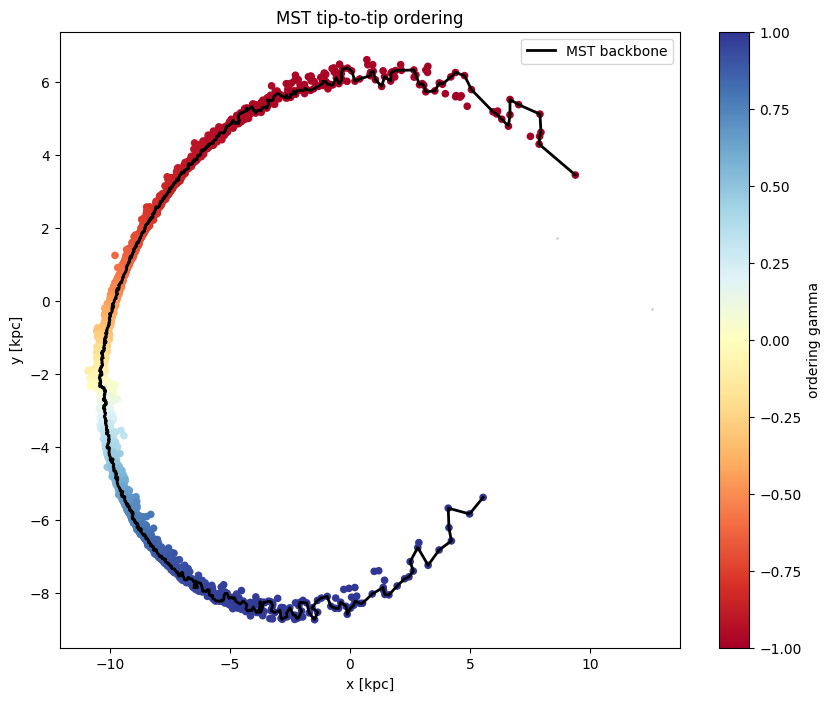

In [7]:
_fig, ax = plt.subplots(figsize=(10, 8))
ax.scatter(qs["x"], qs["y"], s=1, c="lightgray")
oq = {k: v[mstresult.ordering] for k, v in mstresult.positions.items()}
timeline = np.linspace(-1, 1, len(mstresult.ordering))
im = ax.scatter(oq["x"], oq["y"], s=20, c=timeline, cmap="RdYlBu")
bx = mstresult.backbone
ax.plot(np.asarray(bx["x"]), np.asarray(bx["y"]), c="k", lw=2, label="MST backbone")
plt.colorbar(im, ax=ax, label="ordering gamma")
ax.set(xlabel="x [kpc]", ylabel="y [kpc]", title="MST tip-to-tip ordering")
ax.legend()
plt.show()

## Autoencoder mean path


In [8]:
key, model_key, train_key = jr.split(key, 3)
normalizer = pcf.nn.StandardScalerNormalizer(qs, ps)
model = pcf.nn.PathAutoencoder.make(
    normalizer, gamma_range=mstresult.gamma_range, key=model_key
)
result, _, losses = pcf.nn.train_autoencoder(model, mstresult, key=train_key)

Training:   0%|          | 0/800 [00:00<?, ?epoch/s]

Training:   0%|          | 0/100 [00:00<?, ?epoch/s]

Training:   0%|          | 0/200 [00:00<?, ?epoch/s]

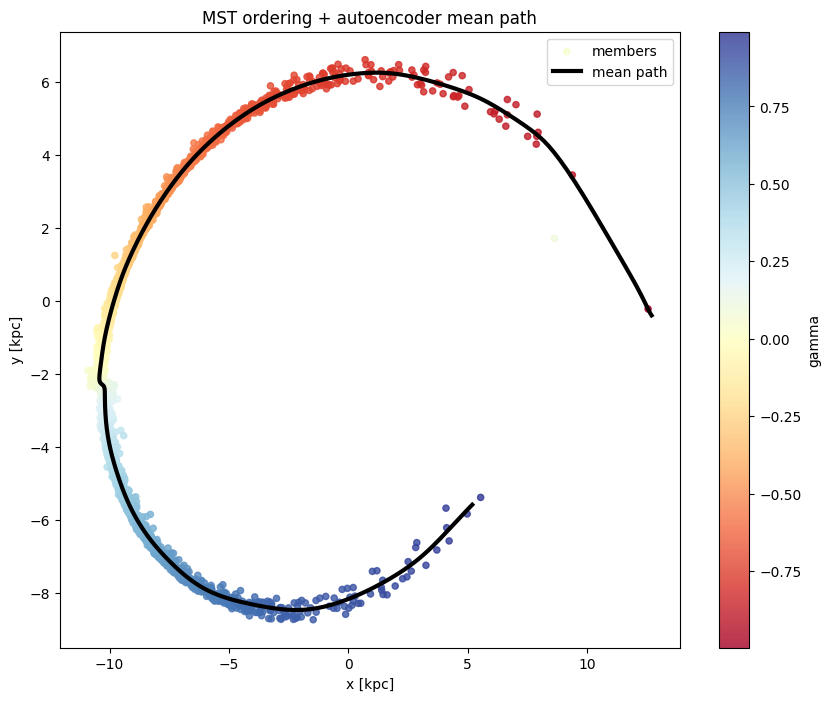

In [9]:
_fig, ax = plt.subplots(figsize=(10, 8))
all_gamma, all_probs = result.model.encode(mstresult.positions, mstresult.velocities)
qs_pred = result(jnp.linspace(*result.gamma_range, 1_000))
im = ax.scatter(
    np.asarray(qs["x"]),
    np.asarray(qs["y"]),
    s=20,
    c=np.asarray(all_gamma),
    cmap="RdYlBu",
    alpha=0.8,
    label="members",
)
ax.plot(
    np.asarray(qs_pred["x"]), np.asarray(qs_pred["y"]), c="k", lw=3, label="mean path"
)
plt.colorbar(im, ax=ax, label="gamma")
ax.set(xlabel="x [kpc]", ylabel="y [kpc]", title="MST ordering + autoencoder mean path")
ax.legend()
plt.show()